## **Menentukan Pertanyaan Bisnis**

1. Bagaimana tren pemasukan dan pengeluaran pengguna setiap bulan selama tahun 2025?
2. Apa saja 5 kategori pengeluaran yang memiliki total nominal tertinggi dalam data transaksi?
3. Berapakah rasio pengeluaran terhadap total pemasukan untuk menentukan tingkat kesehatan finansial pengguna?
4. Pada periode bulan apa saja pengguna mengalami kondisi defisit (pengeluaran > pemasukan) yang berisiko bagi likuiditas?
5. Bagaimana pola pertumbuhan pengeluaran pengguna di setiap kuartal selama setahun terakhir?
6. Rekomendasi apa yang bisa dilakukan supaya pengeluaran untuk Loan given tidak mengganggu kondisi keuangan?

## **Import Library yang Digunakan**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Data Wrangling**

### 1. Gathering Data

In [2]:
income_df = pd.read_csv('Income.csv')
income_df.head()

,date_time,category,account,amount,currency,tags
0,2025-11-29 00:00:00,Job,acct_1,49,BYN,tag_1
1,2025-11-29 00:00:00,Job,acct_1,18,BYN,tag_2
2,2025-11-29 00:00:00,Job,acct_1,32,BYN,tag_3
3,2025-11-29 00:00:00,Job,acct_1,109,BYN,tag_4
4,2025-11-28 00:00:00,Second work,acct_1,132,BYN,2th_work


In [3]:
expenses_df = pd.read_csv('Expenses.csv')
expenses_df.head()

,date_time,category,account,amount,currency,tags
0,2025-11-30 00:00:00,Health,acct_1,114.0,BYN,tag_1
1,2025-11-29 00:00:00,Food,acct_1,5.0,BYN,tag_1
2,2025-11-27 00:00:00,Public transport,acct_2,1.0,BYN,tag_1
3,2025-11-27 00:00:00,Cafe,acct_1,10.0,BYN,tag_1
4,2025-11-27 00:00:00,Public transport,acct_2,1.0,BYN,tag_1


**Insight**:
- Data terdiri dari dua jenis transaksi utama, yaitu pemasukan dan pengeluaran.
- Setiap transaksi memiliki atribut penting seperti waktu transaksi (date_time), kategori (category), jumlah transaksi (amount), serta akun yang digunakan (account).
- Data bersifat terstruktur sehingga dapat langsung digunakan untuk proses analisis lebih lanjut.

## 2. Assesing Data

##### Menilai tabel income

In [4]:
# cek struktur data
income_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date_time  355 non-null    object
 1   category   355 non-null    object
 2   account    355 non-null    object
 3   amount     355 non-null    int64 
 4   currency   355 non-null    object
 5   tags       355 non-null    object
dtypes: int64(1), object(5)
memory usage: 16.8+ KB


In [5]:
# cek missing value
income_df.isna().sum()

,0
date_time,0
category,0
account,0
amount,0
currency,0
tags,0


In [6]:
# cek duplikasi
income_df.duplicated().sum()

np.int64(6)

In [7]:
# statistik deskriptif
income_df.describe()

,amount
count,355.000000
mean,75.478873
std,148.986184
min,2.000000
25%,19.000000
50%,36.000000
75%,67.000000
max,1506.000000


In [8]:
# cek outlier
columns = ["amount"]

print("DETEKSI OUTLIER MENGGUNAKAN IQR\n")

for col in columns:
    Q1 = income_df[col].quantile(0.25)
    Q3 = income_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = income_df[(income_df[col] < lower_bound) | (income_df[col] > upper_bound)]

    print(f"Kolom: {col}")
    print(f"Q1            : {Q1}")
    print(f"Q3            : {Q3}")
    print(f"IQR           : {IQR}")
    print(f"Lower Bound   : {lower_bound}")
    print(f"Upper Bound   : {upper_bound}")
    print(f"Jumlah Outlier: {len(outliers)}")
    print("-" * 40)

DETEKSI OUTLIER MENGGUNAKAN IQR

Kolom: amount
Q1            : 19.0
Q3            : 67.0
IQR           : 48.0
Lower Bound   : -53.0
Upper Bound   : 139.0
Jumlah Outlier: 43
----------------------------------------


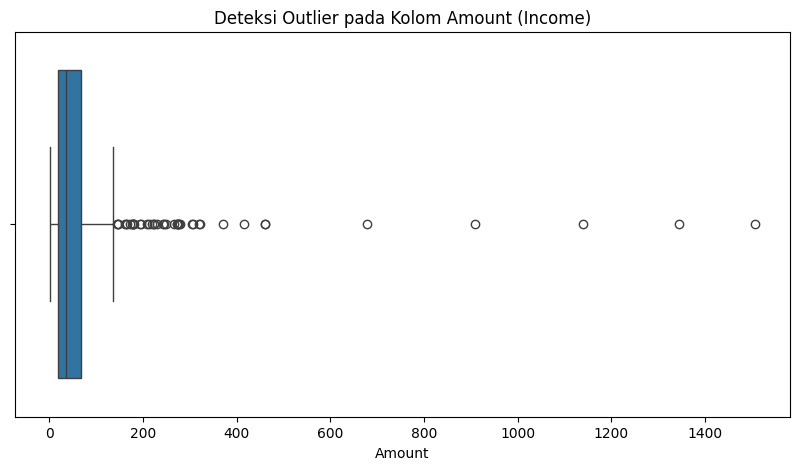

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(x=income_df["amount"])
plt.title("Deteksi Outlier pada Kolom Amount (Income)")
plt.xlabel("Amount")
plt.show()

##### Menilai tabel expenses

In [10]:
# cek struktur data
expenses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date_time  938 non-null    object 
 1   category   938 non-null    object 
 2   account    938 non-null    object 
 3   amount     938 non-null    float64
 4   currency   938 non-null    object 
 5   tags       938 non-null    object 
dtypes: float64(1), object(5)
memory usage: 44.1+ KB


In [11]:
# cek missing value
expenses_df.isna().sum()

,0
date_time,0
category,0
account,0
amount,0
currency,0
tags,0


In [12]:
# cek duplikasi
expenses_df.duplicated().sum()

np.int64(145)

In [13]:
# statistik deskriptif
expenses_df.describe()

,amount
count,938.000000
mean,15.842217
std,78.291145
min,0.000000
25%,1.000000
50%,2.000000
75%,10.000000
max,1172.000000


In [14]:
# cek outlier
columns = ["amount"]

print("DETEKSI OUTLIER MENGGUNAKAN IQR\n")

for col in columns:
    Q1 = expenses_df[col].quantile(0.25)
    Q3 = expenses_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = expenses_df[(expenses_df[col] < lower_bound) | (expenses_df[col] > upper_bound)]

    print(f"Kolom: {col}")
    print(f"Q1            : {Q1}")
    print(f"Q3            : {Q3}")
    print(f"IQR           : {IQR}")
    print(f"Lower Bound   : {lower_bound}")
    print(f"Upper Bound   : {upper_bound}")
    print(f"Jumlah Outlier: {len(outliers)}")
    print("-" * 40)

DETEKSI OUTLIER MENGGUNAKAN IQR

Kolom: amount
Q1            : 1.0
Q3            : 10.0
IQR           : 9.0
Lower Bound   : -12.5
Upper Bound   : 23.5
Jumlah Outlier: 99
----------------------------------------


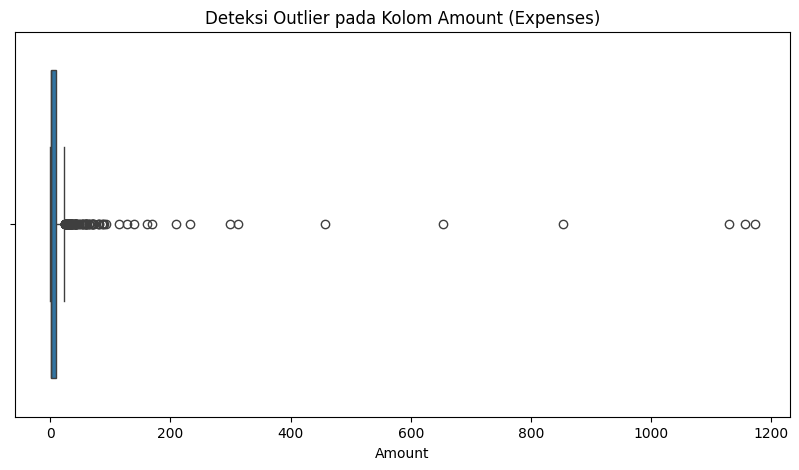

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x=expenses_df["amount"])
plt.title("Deteksi Outlier pada Kolom Amount (Expenses)")
plt.xlabel("Amount")
plt.show()

**Insight**:
- Dataset memiliki struktur yang jelas dengan beberapa atribut utama seperti date_time, category, amount, dan account. Seluruh kolom memiliki tipe data yang sesuai, meskipun kolom waktu (date_time) perlu dikonversi ke format datetime agar dapat dianalisis secara temporal.
- Tidak ditemukan nilai kosong (missing values) pada dataset, sehingga data dapat langsung digunakan tanpa perlu penanganan imputasi.
- Ditemukan adanya data duplikat pada kedua dataset, sehingga diperlukan proses penghapusan duplikasi untuk menjaga keakuratan analisis.
- Hasil pemeriksaan awal menunjukkan adanya variasi nilai pada kolom amount, termasuk kemungkinan nilai ekstrem (outlier), yang perlu diperhatikan pada tahap analisis berikutnya.
- Secara umum, data sudah konsisten dan tidak ditemukan anomali struktur yang signifikan, sehingga dataset dapat dilanjutkan ke tahap pembersihan (data cleaning).

## **Cleaning Data**

##### Membersihkan tabel income

In [16]:
# ubah tipe data date_time
income_df['date_time'] = pd.to_datetime(income_df['date_time'])

In [17]:
# tambah fitur bulan
income_df['month'] = income_df['date_time'].dt.month

In [18]:
# hapus duplikasi
income_df.drop_duplicates(inplace=True)

In [19]:
# cek duplikasi setelah cleaning
print("Jumlah duplikat:", income_df.duplicated().sum())

Jumlah duplikat: 0


In [20]:
# cek struktur data setelah cleaning
income_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349 entries, 0 to 354
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date_time  349 non-null    datetime64[ns]
 1   category   349 non-null    object        
 2   account    349 non-null    object        
 3   amount     349 non-null    int64         
 4   currency   349 non-null    object        
 5   tags       349 non-null    object        
 6   month      349 non-null    int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(4)
memory usage: 20.4+ KB


In [21]:
# statistik deskriptif
income_df.describe()

,date_time,amount,month
count,349,349.000000,349.000000
mean,2025-06-17 12:35:04.297993984,76.300860,6.048711
min,2025-01-03 00:00:00,2.000000,1.000000
25%,2025-03-23 00:00:00,20.000000,3.000000
50%,2025-06-20 00:00:00,36.000000,6.000000
75%,2025-09-11 00:00:00,67.000000,9.000000
max,2025-11-29 00:00:00,1506.000000,11.000000
std,NaN,150.098066,3.154167


In [22]:
# lihat data
income_df.head()

,date_time,category,account,amount,currency,tags,month
0,2025-11-29,Job,acct_1,49,BYN,tag_1,11
1,2025-11-29,Job,acct_1,18,BYN,tag_2,11
2,2025-11-29,Job,acct_1,32,BYN,tag_3,11
3,2025-11-29,Job,acct_1,109,BYN,tag_4,11
4,2025-11-28,Second work,acct_1,132,BYN,2th_work,11


##### Membersihkan tabel expenses

In [23]:
# ubah tipe data date_time
expenses_df['date_time'] = pd.to_datetime(expenses_df['date_time'])

In [24]:
# tambah fitur bulan
expenses_df['month'] = expenses_df['date_time'].dt.month

In [25]:
# hapus duplikasi
expenses_df.drop_duplicates(inplace=True)

In [26]:
# cek duplikasi setelah cleaning
print("Jumlah duplikat:", expenses_df.duplicated().sum())

Jumlah duplikat: 0


In [27]:
# cek struktur data setelah cleaning
expenses_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 793 entries, 0 to 937
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date_time  793 non-null    datetime64[ns]
 1   category   793 non-null    object        
 2   account    793 non-null    object        
 3   amount     793 non-null    float64       
 4   currency   793 non-null    object        
 5   tags       793 non-null    object        
 6   month      793 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(4)
memory usage: 46.5+ KB


In [28]:
# statistik deskriptif
expenses_df.describe()

,date_time,amount,month
count,793,793.000000,793.000000
mean,2025-06-26 07:55:45.775535872,18.528373,6.331652
min,2025-01-07 00:00:00,0.000000,1.000000
25%,2025-04-05 00:00:00,1.000000,4.000000
50%,2025-06-30 00:00:00,5.000000,6.000000
75%,2025-09-17 00:00:00,12.000000,9.000000
max,2025-11-30 00:00:00,1172.000000,11.000000
std,NaN,84.881525,3.022177


In [29]:
# lihat data
expenses_df.head()

,date_time,category,account,amount,currency,tags,month
0,2025-11-30,Health,acct_1,114.0,BYN,tag_1,11
1,2025-11-29,Food,acct_1,5.0,BYN,tag_1,11
2,2025-11-27,Public transport,acct_2,1.0,BYN,tag_1,11
3,2025-11-27,Cafe,acct_1,10.0,BYN,tag_1,11
5,2025-11-26,Cafe,acct_3,2.0,BYN,tag_1,11


**Insight**:
- Kolom date_time telah dikonversi ke format datetime untuk memudahkan analisis berbasis waktu, seperti pengelompokan berdasarkan bulan.
- Ditambahkan atribut baru berupa month yang diambil dari kolom date_time untuk mendukung analisis tren temporal.
- Data duplikat telah dihapus untuk menghindari perhitungan ganda yang dapat mempengaruhi hasil analisis.
- Tidak ditemukan missing value pada dataset, sehingga tidak diperlukan proses imputasi atau penghapusan data.
- Setelah proses cleaning, struktur data menjadi lebih rapi, konsisten, dan siap digunakan untuk tahap eksplorasi data (EDA).

## **Exploratory Data Analysis (EDA)**

### A. Explore tabel income

#### 1. Univariate Analysis

In [30]:
income_df.sample(5)

,date_time,category,account,amount,currency,tags,month
354,2025-01-03,Job,acct_1,34,BYN,tag_5,1
28,2025-10-28,Gift,acct_1,176,BYN,tag_5,10
34,2025-10-25,Second work,acct_1,371,BYN,2th_work,10
70,2025-09-25,Gift,acct_1,79,BYN,tag_5,9
320,2025-02-02,Gift,acct_1,35,BYN,tag_5,2


In [31]:
# pola pemasukan pengguna
income_df['amount'].describe()

,amount
count,349.000000
mean,76.300860
std,150.098066
min,2.000000
25%,20.000000
50%,36.000000
75%,67.000000
max,1506.000000


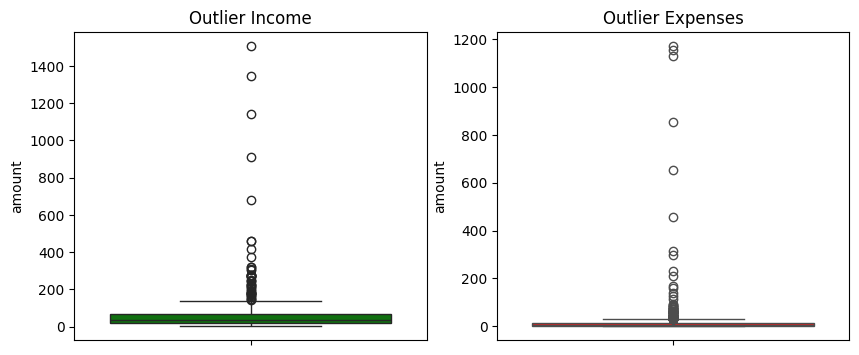

In [32]:
# visualisasi outlier
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=income_df['amount'], color='green')
plt.title('Outlier Income')

plt.subplot(1, 2, 2)
sns.boxplot(y=expenses_df['amount'], color='red')
plt.title('Outlier Expenses')
plt.show()

In [33]:
# Penanganan outlier untuk melihat detail transaksi outlier yang di atas 600
print("Detail Outlier Pemasukan:")
display(income_df[income_df['amount'] > 600].sort_values(by='amount', ascending=False))

print("\nDetail Outlier Pengeluaran:")
display(expenses_df[expenses_df['amount'] > 600].sort_values(by='amount', ascending=False))

Detail Outlier Pemasukan:


,date_time,category,account,amount,currency,tags,month
75,2025-09-23,Gift,acct_1,1506,BYN,tag_5,9
37,2025-10-20,Debt return / Borrowed money,acct_1,1345,BYN,tag_5,10
64,2025-09-27,Gift,acct_1,1140,BYN,tag_5,9
223,2025-05-09,Other,acct_1,908,BYN,tag_5,5
71,2025-09-25,Gift,acct_1,678,BYN,tag_5,9



Detail Outlier Pengeluaran:


,date_time,category,account,amount,currency,tags,month
808,2025-03-05,Loan given,acct_1,1172.0,BYN,tag_1,3
809,2025-03-05,Other,acct_1,1156.0,BYN,tag_1,3
207,2025-09-29,Bought for myself,acct_1,1129.0,BYN,tag_1,9
140,2025-10-15,Loan given,acct_1,854.0,BYN,tag_1,10
638,2025-04-29,Other,acct_1,654.0,BYN,tag_1,4


**Insight**: Berdasarkan visualisasi boxplot, ditemukan beberapa transaksi dengan nilai ekstrem (di atas 600 BYN). Setelah dilakukan pengecekan pada data mentah, transaksi-transaksi tersebut merupakan data yang valid dan mencerminkan transaksi nyata seperti pembayaran besar atau pendapatan sampingan yang signifikan. Oleh karena itu, data ini tidak dihapus agar analisis total saldo dan kondisi finansial tetap mencerminkan realita keuangan pengguna.

#### 2. Multivariate Analysis

##### a. Analisis Komposisi Pemasukan per Kategori
Bagian ini dilakukan untuk melihat distribusi total uang yang masuk berdasarkan sumbernya secara mendetail

In [34]:
# kategori income paling dominan
income_by_category = income_df.groupby("category")["amount"].sum().sort_values(ascending=False)
income_by_category

,amount
category,
Second work,8504
Job,7808
Gift,4635
Debt return / Borrowed money,2759
Other,2691
Cashback,174
Deposit interest,58


**Insight:** Berdasarkan data di atas, terlihat bahwa sumber pemasukan terbesar pengguna berasal dari 'Second work' dan 'Job', sementara deposit interest dan cashback memberikan kontribusi yang paling kecil.

##### b. Explore Tren Pemasukan dan Pengeluaran
Bagian ini dilakukan untuk melihat bagaimana jumlah uang yang masuk berubah-ubah atau naik-turun setiap bulannya selama setahun

In [35]:
# tren pemasukan dari waktu ke waktu
income_monthly = income_df.groupby("month")["amount"].sum()
income_monthly

,amount
month,
1,1864
2,1647
3,3092
4,1423
5,2010
6,2227
7,1967
8,2359
9,5730


**Insight:** Dari data di atas, terlihat bahwa jumlah pemasukan bulanan tidak stabil. Pemasukan paling tinggi ada di bulan ke-9 sebesar 5.730, sedangkan yang paling rendah ada di bulan ke-11 dengan besar 1.317. Perbedaan yang jauh ini menunjukkan kalau pendapatan user sangat berubah-ubah setiap bulannya

##### Explore tabel expenses

In [36]:
expenses_df.sample(5)

,date_time,category,account,amount,currency,tags,month
270,2025-09-10,Food,acct_1,5.0,BYN,tag_1,9
683,2025-04-11,Clothes,acct_1,161.0,BYN,tag_1,4
159,2025-10-13,Leisure,acct_3,35.0,BYN,tag_1,10
178,2025-10-05,Public transport,acct_2,1.0,BYN,tag_1,10
485,2025-06-26,Cafe,acct_1,11.0,BYN,tag_1,6


#### 1. Univariate Analysis: Statistik Deskriptif Pengeluaran
Bagian ini dilakukan untuk melihat ringkasan statistik dari nominal pengeluaran untuk memahami gambaran umum nilai transaksi pengguna/user

In [37]:
# pola pengeluaran pengguna
expenses_df['amount'].describe()

,amount
count,793.000000
mean,18.528373
std,84.881525
min,0.000000
25%,1.000000
50%,5.000000
75%,12.000000
max,1172.000000


**Insight:** Rata-rata pengeluaran pengguna adalah 18.528373, namun terdapat nilai maksimum yang sangat besar mencapai 1172.000000. Hal ini menunjukkan adanya transaksi tunggal yang jumlahnya jauh di atas rata-rata pengeluaran harian

##### 2. Multivariate Analysis: Distribusi kategori & Tren bulanan
tujuannya untuk membedah total pengeluaran berdasarkan kelompok kategori dan melihat perubahan jumlah pengeluaran setiap bulannya.

In [38]:
# kategori pengeluaran paling dominan
expenses_by_category = expenses_df.groupby("category")["amount"].sum().sort_values(ascending=False)
expenses_by_category

,amount
category,
Loan given,2809.0
Other,2699.0
Food,1528.0
Cafe,1413.0
Gifts,1277.0
Bought for myself,1273.0
Leisure,945.0
Health,804.0
Taxi,770.0


**Insight:** Kategori Loan given dan Other merupakan pengeluaran terbesar. Besarnya dana yang dialokasikan untuk pinjaman (Loan given) dapat berisiko membuat kondisi keuangan pengguna jadi kurang fleksibel atau kekurangan dana saat dibutuhkan

In [39]:
# tren pengeluaran dari waktu ke waktu
expenses_monthly = expenses_df.groupby("month")["amount"].sum()
expenses_monthly

,amount
month,
1,969.0
2,615.0
3,3272.0
4,1167.0
5,633.0
6,682.0
7,811.0
8,828.0
9,2906.0


**Insight:** Pengeluaran mengalami kenaikan yang tinggi pada bulan ke-3 yaitu sebesar 3.272 dan bulan ke-9 sebesar 2.906. Kenaikan ini perlu diperhatikan untuk melihat apakah ada kebutuhan musiman atau pengeluaran tak terduga

##### Explore income dan expenses

##### Multivariate Analysis: Perbandingan Income dan Expenses
Dilakukan untuk membandingkan total income dan total expenses untuk melihat gambaran besar kesehatan finansial pengguna serta menghitung sisa saldo (net income) bulanan.

In [40]:
income_df['type'] = 'income'
expenses_df['type'] = 'expenses'

df = pd.concat([income_df, expenses_df])

In [41]:
# perbandingan total income dan expenses
total = df.groupby('type')['amount'].sum()
total

,amount
type,
expenses,14693.0
income,26629.0


**Insight:** Secara total, pemasukan pengguna sebesar 26.629 jauh lebih besar dibandingkan pengeluarannya yaitu 14.693. Ini adalah indikator awal yang positif karena pengguna memiliki surplus dana secara keseluruhan.

In [42]:
# tren income vs expenses per bulan
monthly = df.groupby(['month', 'type'])['amount'].sum().unstack()
monthly

type,expenses,income
month,,
1,969.0,1864.0
2,615.0,1647.0
3,3272.0,3092.0
4,1167.0,1423.0
5,633.0,2010.0
6,682.0,2227.0
7,811.0,1967.0
8,828.0,2359.0
9,2906.0,5730.0


In [43]:
# rasio expenses terhadap income
income_total = income_df['amount'].sum()
expenses_total = expenses_df['amount'].sum()

ratio = expenses_total / income_total
print("Rasio Expenses/Income:", ratio)

Rasio Expenses/Income: 0.5517668707048706


**Insight:** Rasio pengeluaran terhadap pemasukan adalah sekitar 0.55 atau 55%. Artinya, dari setiap 100 BYN yang masuk, pengguna menghabiskan 55 BYN. Angka ini menunjukkan kondisi keuangan yang cukup sehat karena pengeluaran masih di bawah 60% dari total pemasukan.

In [44]:
# saldo bulanan
monthly['net'] = monthly['income'] - monthly['expenses']
monthly['net']

,net
month,
1,895.0
2,1032.0
3,-180.0
4,256.0
5,1377.0
6,1545.0
7,1156.0
8,1531.0
9,2824.0


**Insight:** Secara keseluruhan memang terjadi surplus, namun saldo bulanan mengalami perubahan yang cukup signifikan. Saldo tertinggi terjadi pada bulan ke-9 sebesar 2.824 karena adanya peningkatan pemasukan pada periode tersebut.

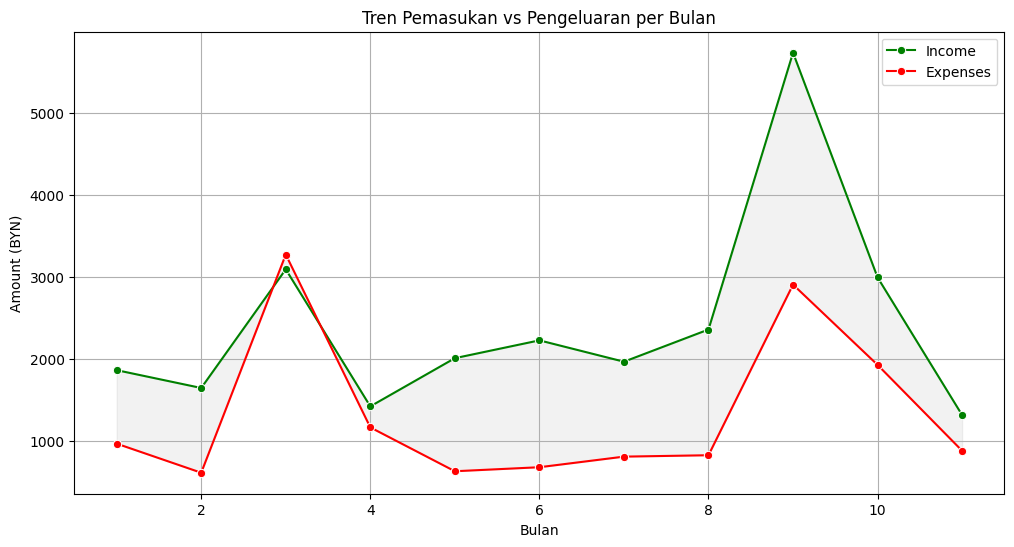

In [45]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x='month', y='income', label='Income', marker='o', color='green')
sns.lineplot(data=monthly, x='month', y='expenses', label='Expenses', marker='o', color='red')
plt.fill_between(monthly.index, monthly['income'], monthly['expenses'], color='gray', alpha=0.1)
plt.title('Tren Pemasukan vs Pengeluaran per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Amount (BYN)')
plt.grid(True)
plt.legend()
plt.show()

sinii

In [46]:
# bulan defisit
monthly[monthly['net'] < 0]

type,expenses,income,net
month,,,
3,3272.0,3092.0,-180.0


**Insight**: Bulan ke-3 menjadi periode yang perlu diperhatikan karena pengeluaran lebih besar dibanding pemasukan (defisit -180 BYN). Kondisi ini menunjukkan risiko keuangan, sehingga pengguna sebaiknya menjaga agar pengeluaran tetap sesuai dengan pendapatan bulanan.

###### Analisis Perbandingan Kategori Pemasukan dan Pengeluaran
Bagian ini bertujuan untuk mengidentifikasi kategori yang paling berkontribusi terhadap pemasukan dan pengeluaran.

In [47]:
# kategori expenses vs income
top_expenses = expenses_df.groupby('category')['amount'].sum().sort_values(ascending=False)
top_income = income_df.groupby('category')['amount'].sum().sort_values(ascending=False)

top_expenses.head()
top_income.head()

,amount
category,
Second work,8504
Job,7808
Gift,4635
Debt return / Borrowed money,2759
Other,2691


**Insight**: Hasil analisis menunjukkan bahwa sumber pemasukan utama berasal dari Second work dan Job. Sementara itu, pengeluaran terbesar terdapat pada kategori Loan given, sehingga terlihat bahwa sebagian besar pendapatan dialokasikan untuk pinjaman

#### Data Exporting
pada tahap ini, data yang telah dibersihkan dan dianalisis disimpan ke dalam format CSV agar dapat digunakan kembali untuk keperluan pembuatan dashboard

In [48]:
# untuk membedakan income expenses
income_df['type'] = 'income'
expenses_df['type'] = 'expenses'

# gabungkan data
final_data = pd.concat([income_df, expenses_df], ignore_index=True)

# simpan csv
final_data.to_csv("main_data.csv", index=False)

print("BERHASIL! File 'main_data.csv' sudah dibuat.")

BERHASIL! File 'main_data.csv' sudah dibuat.


**Insight:**
- Berdasarkan analisis deskriptif, baik pemasukan maupun pengeluaran menunjukkan variasi nilai yang cukup besar.
- Kategori pengeluaran tertentu memiliki kontribusi paling besar terhadap total pengeluaran.
- Hasil analisis menunjukkan bahwa perbandingan antara pemasukan dan pengeluaran menjadi indikator utama kondisi finansial.
- Ditemukan bahwa pada periode tertentu terdapat kondisi di mana pengeluaran melebihi pemasukan (net negatif).
- Pengeluaran pengguna menunjukkan fluktuasi dari waktu ke waktu, dengan adanya peningkatan pada periode tertentu.

## **Data Visualization & Explanatory Analysis**
Tahap ini dilakukan untuk menganalisis secara mendalam (Explanatory Analysis) untuk menjawab pertanyaan bisnis yang telah ditetapkan sebelumnya. Data yang telah dibersihkan pada tahap Wrangling dan EDA akan divisualisasikan dalam bentuk grafik agar lebih mudah dipahami.

### Pertanyaan 1: Bagaimana tren pemasukan dan pengeluaran pengguna setiap bulan selama tahun 2025?

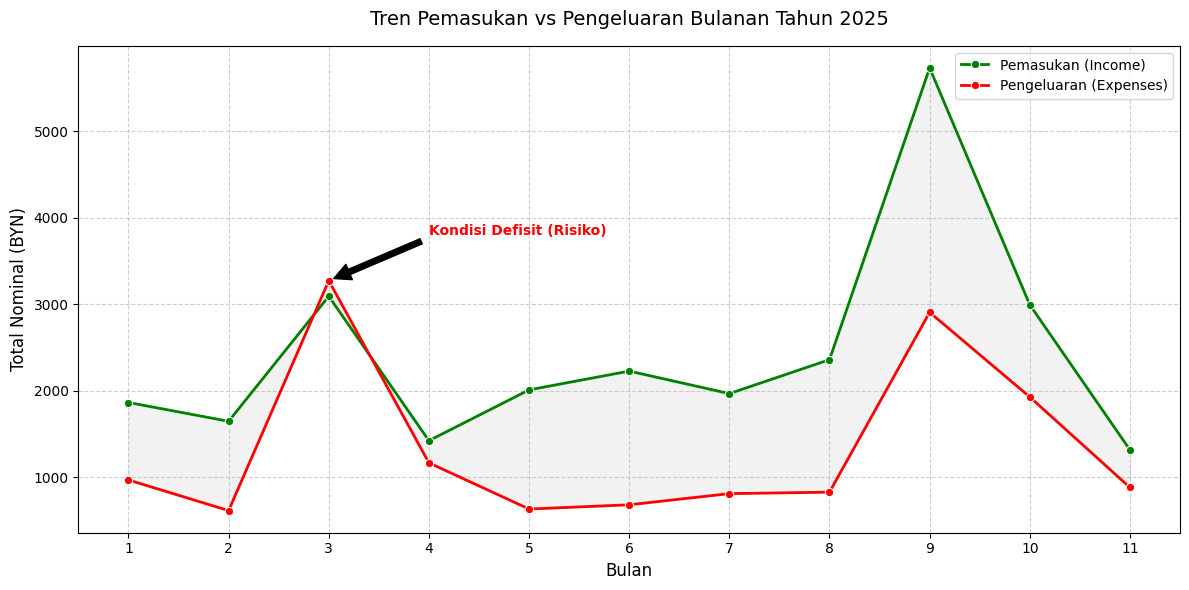

In [49]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=monthly, x='month', y='income', label='Pemasukan (Income)', marker='o', color='green', linewidth=2)
sns.lineplot(data=monthly, x='month', y='expenses', label='Pengeluaran (Expenses)', marker='o', color='red', linewidth=2)

plt.fill_between(monthly.index, monthly['income'], monthly['expenses'], color='gray', alpha=0.1)

# Tambahkan anotasi untuk bulan defisit (Bulan 3)
plt.annotate('Kondisi Defisit (Risiko)', xy=(3, 3272), xytext=(4, 3800),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, color='red', fontweight='bold')

plt.title('Tren Pemasukan vs Pengeluaran Bulanan Tahun 2025', fontsize=14, pad=15)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Nominal (BYN)', fontsize=12)
plt.xticks(range(1, 12))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Insight**: Tren keuangan tahun 2025 menunjukkan bahwa pemasukan pengguna sangat fluktuatif dengan puncak tertinggi terjadi pada bulan ke-9 (September). Meskipun pengeluaran cenderung mengikuti arah pemasukan, terdapat gap yang cukup lebar di sebagian besar bulan, menandakan adanya kemampuan menabung yang baik

### Pertanyaan 2: Apa saja 5 kategori pengeluaran yang memiliki total nominal tertinggi dalam data transaksi?

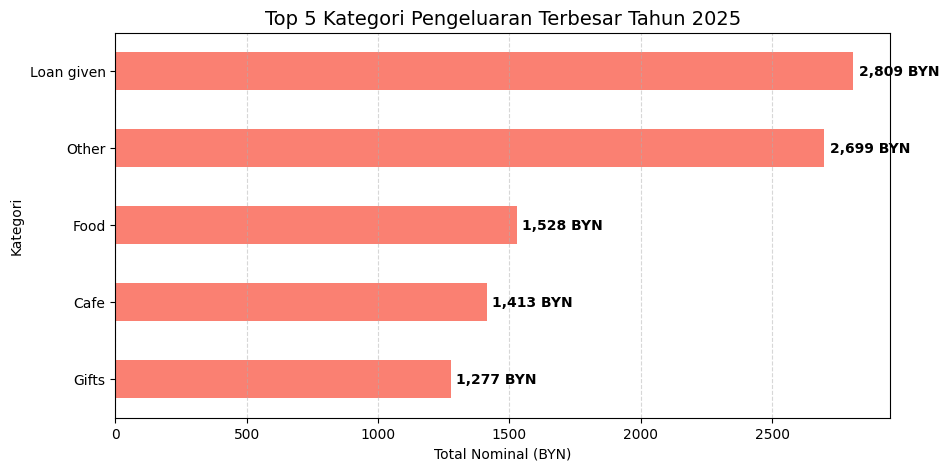

In [50]:
# ambil 5 teratas
top_5_expenses = expenses_df.groupby("category")["amount"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
ax = top_5_expenses.plot(kind='barh', color='salmon')

for i, v in enumerate(top_5_expenses):
    ax.text(v + 20, i, f"{v:,.0f} BYN", va='center', fontweight='bold')

plt.title('Top 5 Kategori Pengeluaran Terbesar Tahun 2025', fontsize=14)
plt.xlabel('Total Nominal (BYN)')
plt.ylabel('Kategori')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

**Insight**: Lima kategori pengeluaran terbesar didominasi oleh Loan given sebesar 2.809 BYN dan Other sebesar 2.699 BYN. Hal ini mengindikasikan bahwa alokasi dana terbesar pengguna bukan untuk kebutuhan pokok, melainkan untuk piutang dan biaya lain-lain. Kategori pendukung berikutnya adalah Food, Cafe, dan Gifts yang mencerminkan gaya hidup bersosialisasi.

### Pertanyaan 3: Berapakah rasio pengeluaran terhadap total pemasukan untuk menentukan tingkat kesehatan finansial pengguna?

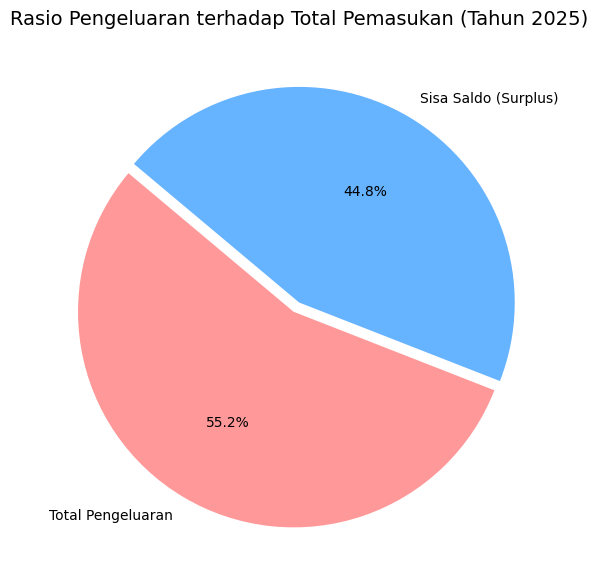

In [51]:
total_inc = income_df['amount'].sum()
total_exp = expenses_df['amount'].sum()
net_surplus = total_inc - total_exp

plt.figure(figsize=(7, 7))
plt.pie([total_exp, net_surplus],
        labels=['Total Pengeluaran', 'Sisa Saldo (Surplus)'],
        autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'],
        startangle=140,
        explode=(0.05, 0))

plt.title('Rasio Pengeluaran terhadap Total Pemasukan (Tahun 2025)', fontsize=14)
plt.show()

**Insight**: Rasio pengeluaran pengguna berada di angka 55,2%, yang berarti pengguna berhasil menyisihkan 44,8% sebagai sisa saldo (surplus). Angka ini menunjukkan kondisi finansial yang sangat sehat, karena idealnya rasio pengeluaran berada di bawah 60%.

### Peertanyaan 4: Pada bulan apa saja pengguna mengalami kondisi defisit, yaitu saat pengeluaran lebih besar dari pemasukan?

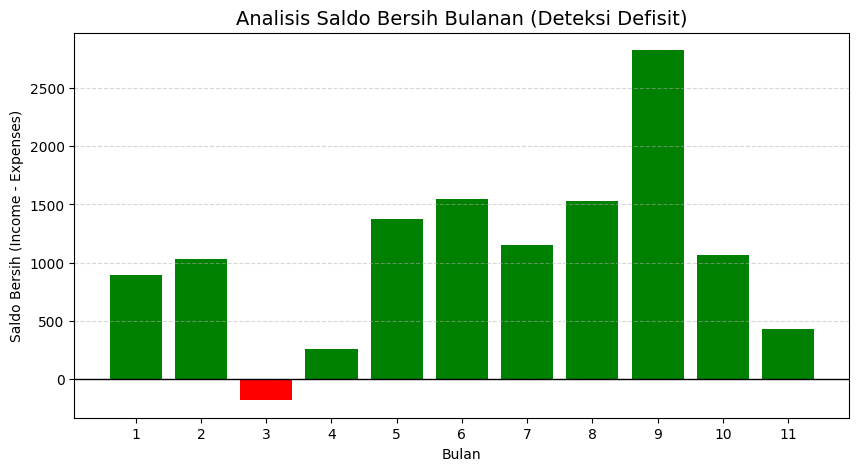

In [52]:
# mencari bulan apa yang pengeluarannya lebih besar dari pemasukan
defisit_months = monthly[monthly['expenses'] > monthly['income']]

plt.figure(figsize=(10, 5))
# membuat bar chart selisih (Net Balance)
monthly['net_balance'] = monthly['income'] - monthly['expenses']
colors = ['green' if x >= 0 else 'red' for x in monthly['net_balance']]

plt.bar(monthly.index, monthly['net_balance'], color=colors)

plt.title('Analisis Saldo Bersih Bulanan (Deteksi Defisit)', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Saldo Bersih (Income - Expenses)')
plt.xticks(range(1, 12))
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Insight**: Melalui deteksi saldo bersih, ditemukan bahwa bulan ke-3 (maret) adalah satu-satunya periode defisit (bar berwarna merah). Hal ini menjadi titik risiko finansial di mana pengguna harus menggunakan dana cadangan untuk menutupi kelebihan pengeluaran pada bulan tersebut.

### Pertanyaan 5: Bagaimana pola pertumbuhan pengeluaran pengguna di setiap kuartal selama setahun terakhir?

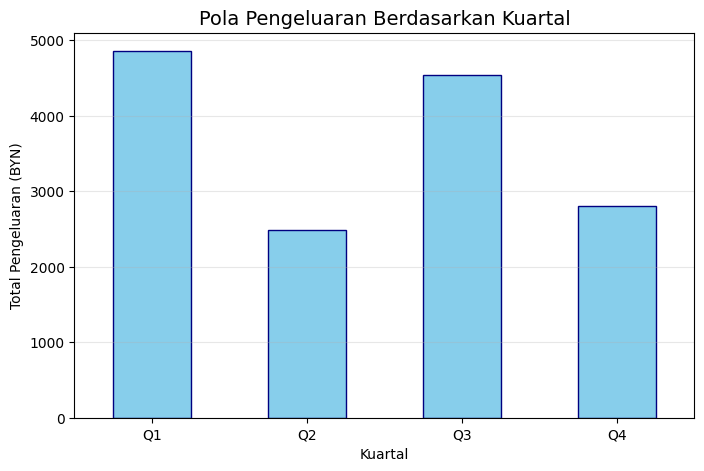

In [53]:
def get_quarter(month):
    if month <= 3: return 'Q1'
    elif month <= 6: return 'Q2'
    elif month <= 9: return 'Q3'
    else: return 'Q4'

expenses_df['quarter'] = expenses_df['month'].apply(get_quarter)
quarterly_data = expenses_df.groupby('quarter')['amount'].sum()

plt.figure(figsize=(8, 5))
quarterly_data.plot(kind='bar', color='skyblue', edgecolor='navy')

plt.title('Pola Pengeluaran Berdasarkan Kuartal', fontsize=14)
plt.xlabel('Kuartal')
plt.ylabel('Total Pengeluaran (BYN)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

**Insight**: Pola pengeluaran per kuartal menunjukkan bahwa Kuartal 1 (Q1) dan Kuartal 3 (Q3) adalah periode dengan pengeluaran paling banyak. Sebaliknya, pada Q2 dan Q4, pengguna cenderung lebih hemat, yang menunjukkan adanya siklus pengeluaran besar setiap beberapa bulan sekali.

### Pertanyaan 6: Rekomendasi apa yang bisa dilakukan supaya pengeluaran untuk Loan given tidak mengganggu kondisi keuangan?

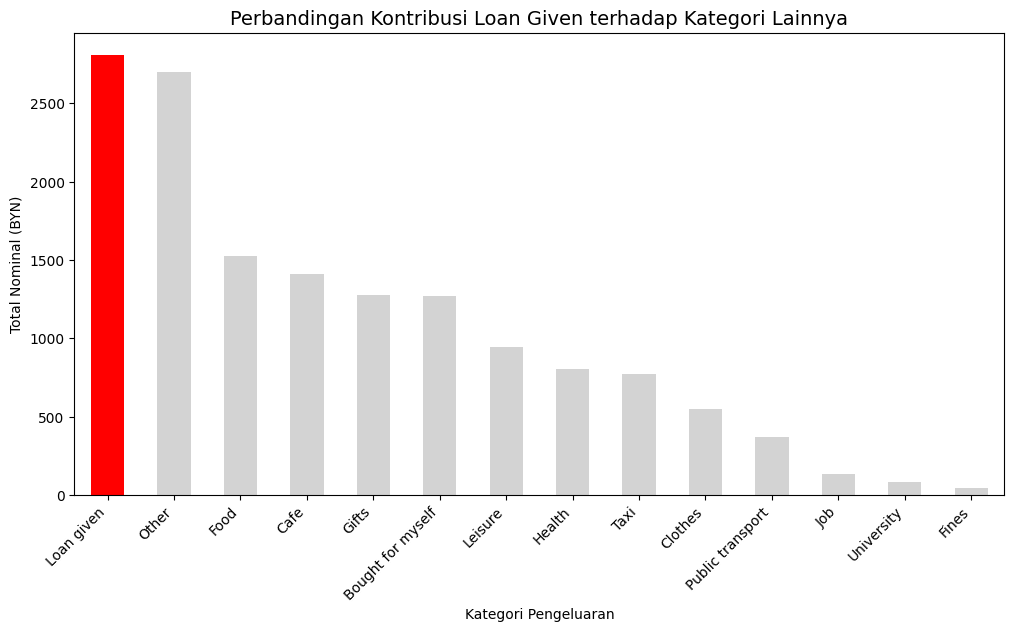

In [54]:
# bandingkan kategori Loan Given dengan rata-rata pengeluaran lainnya
cat_spending = expenses_df.groupby('category')['amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['red' if x == 'Loan given' else 'lightgrey' for x in cat_spending.index]
cat_spending.plot(kind='bar', color=colors)

plt.title('Perbandingan Kontribusi Loan Given terhadap Kategori Lainnya', fontsize=14)
plt.xlabel('Kategori Pengeluaran')
plt.ylabel('Total Nominal (BYN)')
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight**: Grafik perbandingan menunjukkan Loan given jauh melampaui pengeluaran pokok seperti Food. Rekomendasi strategisnya adalah pengguna perlu menetapkan batas maksimal (budget limit) untuk pemberian pinjaman agar tidak memicu defisit berulang seperti yang terjadi pada bulan ke-3.

## **Conclusion**
Berdasarkan seluruh tahapan analisis data yang telah dilakukan, dapat ditarik kesimpulan sebagai berikut:

* Stabilitas Keuangan: Pengguna memiliki kondisi finansial yang sangat baik dengan tingkat surplus mencapai 44,8%. Pemasukan utama didorong oleh pendapatan ganda (Second work dan Job).

* Manajemen Risiko: Meskipun sehat, risiko defisit tetap ada pada periode tertentu (bulan maret). Hal ini membuktikan bahwa pencatatan melalui aplikasi SAFEIN sangat penting untuk memantau kapan pengeluaran mulai melampaui pendapatan harian.

* Prioritas Alokasi: Pengeluaran terbesar pengguna saat ini dialokasikan untuk piutang (Loan given). Untuk meningkatkan kesehatan finansial jangka panjang, pengguna disarankan mengalihkan sebagian alokasi piutang tersebut ke dalam instrumen investasi atau dana darurat guna menjaga likuiditas kas.

* Siklus Pengeluaran: Adanya pola pengeluaran tinggi di Q1 dan Q3 menyarankan pengguna untuk melakukan perencanaan anggaran yang lebih ketat menjelang awal kuartal tersebut agar saldo tetap stabil.

## **Data Dictionary**

In [55]:
data_dict = {
    'Nama Kolom': ['date_time', 'amount', 'category', 'type', 'month', 'month_name', 'quarter'],
    'Tipe Data': ['Datetime', 'Float', 'String', 'String', 'Integer', 'String', 'String'],
    'Deskripsi': [
        'Tanggal dan waktu transaksi',
        'Nominal jumlah uang (BYN)',
        'Kategori transaksi (Food, Job, dll)',
        'Jenis (income atau expenses)',
        'Angka bulan (1-12)',
        'Nama singkat bulan (Jan, Feb, dll)',
        'Periode Kuartal (Q1-Q4)'
    ]
}

df_dict = pd.DataFrame(data_dict)

# export ke CSV
df_dict.to_csv("data_dictionary_safein.csv", index=False)

print("File 'data_dictionary_safein.csv' berhasil dibuat!")

File 'data_dictionary_safein.csv' berhasil dibuat!
